# Hamiltoniano Tight-Binding — Rede Honeycomb de Ressonadores CPW

**Valentina Spohr · IC PIBIC 2025-2026 · IFGW UNICAMP**  
Orientador: Francisco Rouxinol

Este notebook calcula o espectro de frequências normais de uma rede honeycomb de 19 hexágonos (54 ressonadores CPW) usando o modelo Hamiltoniano tight-binding:

$$H_{ij} = f_0 \, \delta_{ij} \;-\; t \cdot A_{ij}$$

onde $A$ é a matriz de adjacência da rede, $f_0$ é a frequência de ressonância individual e $t$ é o parâmetro de hopping capacitivo.

---
**Estrutura do notebook:**
1. [Imports e Parâmetros Globais](#sec1)
2. [Frequência de Ressonância do Ressonador Isolado](#sec2)
3. [Parâmetro de Hopping $t$](#sec3)
4. [Validação: Hexágono Simples (6 ressonadores)](#sec4)
5. [Geometria da Rede Honeycomb (19 hexágonos)](#sec5)
6. [Hamiltoniano Completo (54 ressonadores)](#sec6)
7. [Espectro de Energia e Visualização](#sec7)


---
## 1. Imports e Parâmetros Globais <a id='sec1'></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import RegularPolygon

# ── Parâmetros físicos do sistema ──────────────────────────────────
F_GHZ   = 6.9        # Frequência de ressonância individual (GHz)
C       = 6e-15      # Capacitância de acoplamento (F)
L       = 8.7e-3     # Comprimento do ressonador (m)
C_L     = 1.7e-10    # Capacitância por unidade de comprimento (F/m)
Z0      = 50         # Impedância característica (Ω)

# Tolerância para comparar coordenadas de vértices
COORD_TOL = 0.02

---
## 2. Frequência de Ressonância do Ressonador Isolado <a id='sec2'></a>

Carrega o resultado da simulação HFSS (`S21 dB`) e identifica o pico de ressonância.  
O parâmetro $S_{21}$ (transmissão) tem um máximo na frequência de ressonância da cavidade.

> **Nota:** Se o arquivo de simulação não estiver na pasta, esta seção usa `F_GHZ` da Seção 1.  
> Para carregar: exporte o `S21 dB` do HFSS e salve como `Simulation results/Resonator 1 - S21 dB.txt`.

In [2]:
# ── Carrega dado simulado de transmissão S21 do ressonador isolado ──────────
# Arquivo esperado: 'Simulation results/Resonator 1 - S21 dB.txt'
# Formato: exportado pelo Ansys HFSS (cabeçalho de 7 linhas, 2 colunas: Freq[GHz], S21[dB])
# Se o arquivo não estiver presente, usa o valor de F_GHZ definido na Seção 1.

import os

S21_FILE = 'Simulation results/Resonator 1 - S21 dB.txt'

if os.path.exists(S21_FILE):
    data = np.genfromtxt(S21_FILE, skip_header=7)
    freq = data[:, 0]
    s21  = data[:, 1]
    f_res = freq[np.argmax(s21)]
    print(f"Arquivo encontrado! Frequência de ressonância (S21 máximo): {f_res:.4f} GHz")

    plt.figure(figsize=(7, 4))
    plt.plot(freq, s21, color='steelblue', linewidth=1.5)
    plt.axvline(f_res, color='tomato', linestyle='--', label=f'$f_0$ = {f_res:.4f} GHz')
    plt.xlabel('Frequência (GHz)'); plt.ylabel('$S_{21}$ (dB)')
    plt.title('Transmissão — Ressonador Isolado (HFSS)')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
else:
    f_res = F_GHZ   # usa valor configurado na Seção 1
    print(f"Arquivo '{S21_FILE}' não encontrado.")
    print(f"Usando f_0 = F_GHZ = {F_GHZ} GHz (definido na Seção 1).")
    print(f"Para carregar os dados, coloque o arquivo exportado do HFSS nesse caminho.")

Arquivo 'Simulation results/Resonator 1 - S21 dB.txt' não encontrado.
Usando f_0 = F_GHZ = 6.9 GHz (definido na Seção 1).
Para carregar os dados, coloque o arquivo exportado do HFSS nesse caminho.


---
## 3. Parâmetro de Hopping $t$ <a id='sec3'></a>

O parâmetro de hopping quantifica a taxa de transferência de energia entre ressonadores vizinhos.  
Para acoplamento capacitivo, a expressão analítica é (Göppl *et al.*):

$$t = -\frac{1}{2} \cdot f_0 \cdot \frac{C}{C_L \cdot l}$$

onde $C$ é a capacitância de acoplamento, $C_L$ é a capacitância por comprimento e $l$ é o comprimento do ressonador.

In [3]:
f_hz = F_GHZ * 1e9   # Converte para Hz

# Fórmula do hopping capacitivo
t = -(1/2) * f_hz * C * 2 / (C_L * L) * 1e-9   # resultado em GHz

print(f"f_0    = {F_GHZ} GHz")
print(f"C      = {C*1e15:.1f} fF")
print(f"l      = {L*1e3:.1f} mm")
print(f"C_L    = {C_L*1e12:.1f} pF/m")
print(f"─────────────────────────────────")
print(f"t      = {t:.6f} GHz  ({t*1e3:.4f} MHz)")
print(f"|t/f0| = {abs(t)/F_GHZ*100:.2f}%  (acoplamento fraco ✓)")

f_0    = 6.9 GHz
C      = 6.0 fF
l      = 8.7 mm
C_L    = 170.0 pF/m
─────────────────────────────────
t      = -0.027992 GHz  (-27.9919 MHz)
|t/f0| = 0.41%  (acoplamento fraco ✓)


---
## 4. Validação: Hexágono Simples (6 ressonadores) <a id='sec4'></a>

Antes de construir a rede completa, validamos o método com um único hexágono (6 nós, 6 arestas).  
Os **autovalores da matriz de adjacência** de um hexágono são conhecidos analiticamente: $\{-2, -1, -1, +1, +1, +2\}$.  
As **frequências normais** do sistema acoplado são então $f_n = f_0 - t \cdot \lambda_n$.

In [4]:
# Matriz de adjacência do hexágono (anel de 6 nós)
edges_hex = [(0,1),(1,2),(2,3),(3,4),(4,5),(5,0)]

A_hex = np.zeros((6, 6))
for i, j in edges_hex:
    A_hex[i, j] = 1
    A_hex[j, i] = 1

print("Matriz de adjacência do hexágono:")
print(A_hex.astype(int))

# Autovalores da adjacência
ev_adj = np.sort(np.linalg.eigvals(A_hex).real)
print(f"\nAutovalores de A: {ev_adj}")
print(f"Teórico esperado: [-2, -1, -1, +1, +1, +2]")

Matriz de adjacência do hexágono:
[[0 1 0 0 0 1]
 [1 0 1 0 0 0]
 [0 1 0 1 0 0]
 [0 0 1 0 1 0]
 [0 0 0 1 0 1]
 [1 0 0 0 1 0]]

Autovalores de A: [-2. -1. -1.  1.  1.  2.]
Teórico esperado: [-2, -1, -1, +1, +1, +2]


Frequências normais do hexágono (GHz):
  Modo 1: 6.84402 GHz  (Δf = -55.98 MHz)
  Modo 2: 6.87201 GHz  (Δf = -27.99 MHz)
  Modo 3: 6.87201 GHz  (Δf = -27.99 MHz)
  Modo 4: 6.92799 GHz  (Δf = +27.99 MHz)
  Modo 5: 6.92799 GHz  (Δf = +27.99 MHz)
  Modo 6: 6.95598 GHz  (Δf = +55.98 MHz)


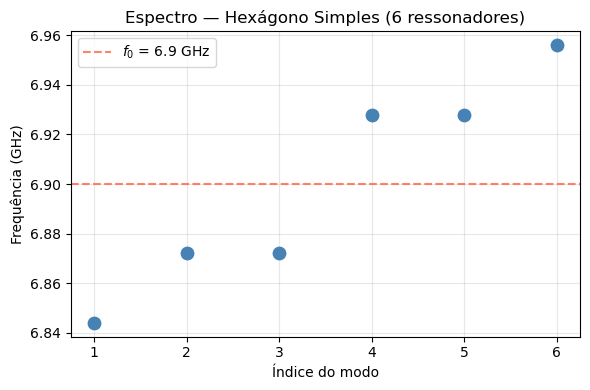

In [5]:
# Hamiltoniano do hexágono: H = f0*I - t*A
H_hex = -t * A_hex
np.fill_diagonal(H_hex, F_GHZ)

freqs_hex = np.sort(np.linalg.eigvals(H_hex).real)
print("Frequências normais do hexágono (GHz):")
for i, f in enumerate(freqs_hex):
    print(f"  Modo {i+1}: {f:.5f} GHz  (Δf = {(f - F_GHZ)*1e3:+.2f} MHz)")

# Visualização
n_hex = np.arange(1, 7)
plt.figure(figsize=(6, 4))
plt.scatter(n_hex, freqs_hex, color='steelblue', s=80, zorder=5)
plt.axhline(F_GHZ, color='tomato', linestyle='--', label=f'$f_0$ = {F_GHZ} GHz', alpha=0.8)
plt.xlabel('Índice do modo'); plt.ylabel('Frequência (GHz)')
plt.title('Espectro — Hexágono Simples (6 ressonadores)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
## 5. Geometria da Rede Honeycomb (19 hexágonos) <a id='sec5'></a>

A rede é composta por 19 hexágonos organizados em 3 camadas concêntricas:
- 1 hexágono central
- 6 hexágonos no anel interno
- 12 hexágonos no anel externo

Os **vértices compartilhados** entre hexágonos vizinhos são os nós da rede (ressonadores).  
O algoritmo abaixo: (1) gera as posições dos 19 hexágonos, (2) coleta todos os vértices únicos, (3) identifica os pares adjacentes (arestas).

In [6]:
def get_hex_vertices(cx, cy, radius):
    """Retorna as 6 coordenadas dos vértices de um hexágono centrado em (cx, cy)."""
    vertices = []
    for i in range(6):
        angle = i * np.pi / 3 + np.pi / 2   # vértice superior primeiro
        vertices.append((cx + radius * np.cos(angle),
                         cy + radius * np.sin(angle)))
    return vertices


def classify_vertex(vx, vy, r_internal=1.4):
    """Classifica vértice em: central, interno ou externo pela distância à origem."""
    d = np.sqrt(vx**2 + vy**2)
    if d < 0.6:   return 'center'
    if d < r_internal: return 'internal'
    return 'external'


def sort_clockwise(vertices):
    """Ordena vértices em sentido horário pela origem."""
    return sorted(vertices, key=lambda v: np.arctan2(v[1], v[0]), reverse=True)


# ── Posições dos 19 hexágonos ──────────────────────────────────────
radius  = 0.5
spacing = radius * np.sqrt(3)
height  = radius * 1.5

hex_positions = [
    (0, 0),                                                            # centro
    ( spacing,    0), ( spacing/2,  height), (-spacing/2,  height),   # anel interno
    (-spacing,    0), (-spacing/2, -height), ( spacing/2, -height),
    ( 2*spacing,  0), ( 1.5*spacing,  height), (  spacing, 2*height), # anel externo
    (0, 2*height), (-spacing, 2*height), (-1.5*spacing,  height),
    (-2*spacing,  0), (-1.5*spacing, -height), (-spacing, -2*height),
    (0, -2*height), (spacing, -2*height), (1.5*spacing, -height)
]

# ── Coletar vértices únicos ────────────────────────────────────────
all_verts_raw = []
for cx, cy in hex_positions:
    for vx, vy in get_hex_vertices(cx, cy, radius):
        is_dup = any(abs(vx - ex) < COORD_TOL and abs(vy - ey) < COORD_TOL
                     for ex, ey in all_verts_raw)
        if not is_dup:
            all_verts_raw.append((vx, vy))

# Separar por categoria e ordenar
cats = {'center': [], 'internal': [], 'external': []}
for vx, vy in all_verts_raw:
    cats[classify_vertex(vx, vy)].append((vx, vy))

all_vertices = (sort_clockwise(cats['center']) +
                sort_clockwise(cats['internal']) +
                sort_clockwise(cats['external']))

vert_to_idx = {v: i for i, v in enumerate(all_vertices)}
print(f"Total de vértices únicos (ressonadores): {len(all_vertices)}")

Total de vértices únicos (ressonadores): 54


In [7]:
def find_adjacent_pairs(hex_positions, all_vertices, radius):
    """
    Encontra todos os pares de vértices que compartilham uma aresta
    em pelo menos um hexágono da rede.
    """
    pairs = set()
    for cx, cy in hex_positions:
        verts = get_hex_vertices(cx, cy, radius)
        for k in range(6):
            v1, v2 = verts[k], verts[(k+1) % 6]
            # encontra índices na lista global
            idx1 = next((vert_to_idx[v] for v in vert_to_idx
                         if abs(v[0]-v1[0]) < COORD_TOL and abs(v[1]-v1[1]) < COORD_TOL), None)
            idx2 = next((vert_to_idx[v] for v in vert_to_idx
                         if abs(v[0]-v2[0]) < COORD_TOL and abs(v[1]-v2[1]) < COORD_TOL), None)
            if idx1 is not None and idx2 is not None:
                pairs.add(tuple(sorted([idx1, idx2])))
    return sorted(pairs)


adjacent_pairs = find_adjacent_pairs(hex_positions, all_vertices, radius)
print(f"Total de arestas (pares adjacentes): {len(adjacent_pairs)}")

# Distribuição de graus
degree = {}
for i, j in adjacent_pairs:
    degree[i] = degree.get(i, 0) + 1
    degree[j] = degree.get(j, 0) + 1

dist = {}
for d in degree.values():
    dist[d] = dist.get(d, 0) + 1
print(f"Grau médio: {2*len(adjacent_pairs)/len(all_vertices):.2f}")
print("Distribuição de graus:", {f"grau {k}": v for k,v in sorted(dist.items())})

Total de arestas (pares adjacentes): 72
Grau médio: 2.67
Distribuição de graus: {'grau 2': 18, 'grau 3': 36}


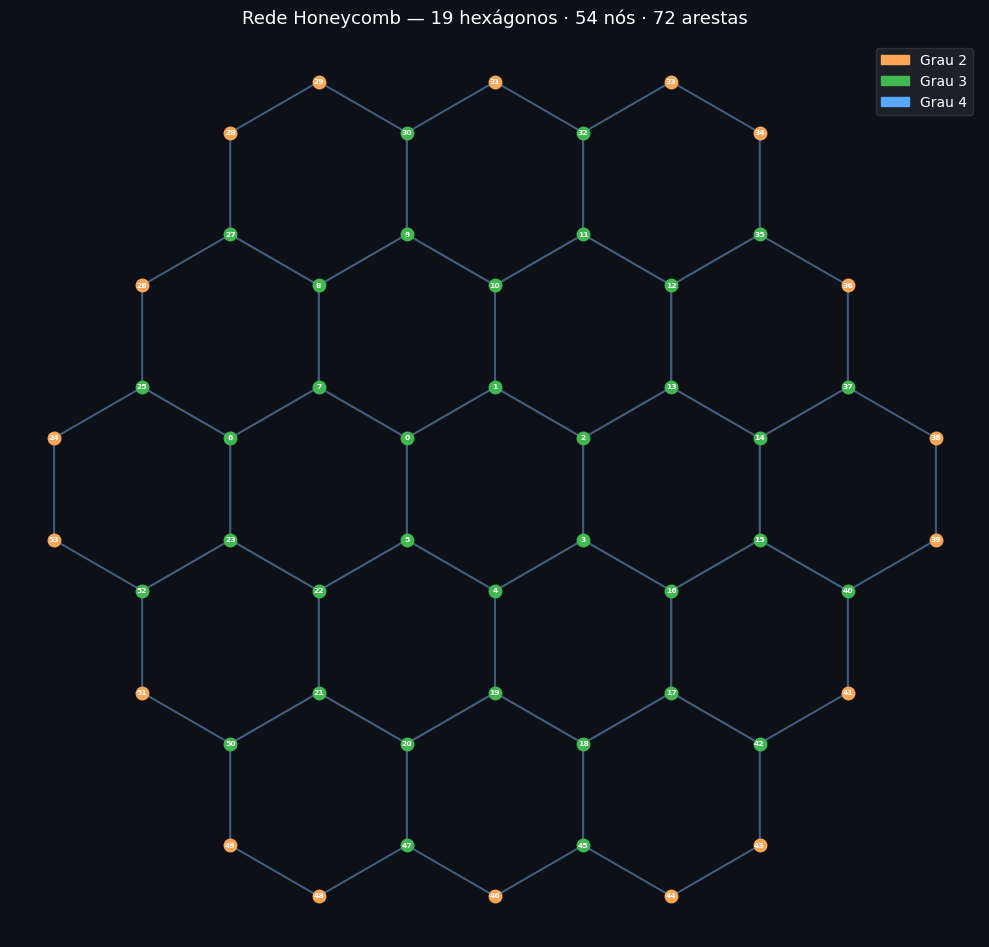

In [8]:
# ── Visualização da rede ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_aspect('equal'); ax.axis('off')
ax.set_facecolor('#0d1117'); fig.patch.set_facecolor('#0d1117')

# Desenhar hexágonos
for cx, cy in hex_positions:
    patch = RegularPolygon((cx, cy), 6, radius=radius,
                           facecolor='none', edgecolor='#30363d', linewidth=1.5)
    ax.add_patch(patch)

# Desenhar arestas
for i, j in adjacent_pairs:
    v1, v2 = all_vertices[i], all_vertices[j]
    ax.plot([v1[0], v2[0]], [v1[1], v2[1]], '-', color='#58a6ff', alpha=0.4, lw=1.2, zorder=3)

# Desenhar nós com cor por grau
cmap = {2: '#ffa657', 3: '#3fb950', 4: '#58a6ff'}
for idx, (vx, vy) in enumerate(all_vertices):
    d = degree.get(idx, 0)
    ax.plot(vx, vy, 'o', color=cmap.get(d, 'white'), markersize=9, zorder=5)
    ax.text(vx, vy, str(idx), color='white', fontsize=5.5,
            ha='center', va='center', zorder=6, fontweight='bold')

legend_patches = [mpatches.Patch(color=c, label=f'Grau {d}') for d, c in cmap.items()]
ax.legend(handles=legend_patches, loc='upper right',
          facecolor='#21262d', labelcolor='white', edgecolor='#30363d', fontsize=10)
ax.set_title(f'Rede Honeycomb — 19 hexágonos · {len(all_vertices)} nós · {len(adjacent_pairs)} arestas',
             color='white', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('honeycomb_rede.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
## 6. Hamiltoniano Completo (54 ressonadores) <a id='sec6'></a>

Com os pares adjacentes determinados, construímos a matriz de adjacência $A$ de dimensão $54 \times 54$  
e o Hamiltoniano tight-binding:

$$H = f_0 \, \mathbb{I}_{54} - t \cdot A$$

Os autovalores de $H$ são as **frequências dos modos normais coletivos** da rede acoplada.

In [9]:
N = len(all_vertices)   # 54

# Matriz de adjacência
A = np.zeros((N, N))
for i, j in adjacent_pairs:
    A[i, j] = 1
    A[j, i] = 1

# Hamiltoniano tight-binding
H = -t * A
np.fill_diagonal(H, F_GHZ * np.ones(N))

print(f"Dimensão do Hamiltoniano: {H.shape}")
print(f"Número de elementos não-nulos fora da diagonal: {np.count_nonzero(A)}")
print(f"Simetria (H == H^T): {np.allclose(H, H.T)}")

# Diagonalização
eigenvalues = np.sort(np.linalg.eigvals(H).real)

print(f"\nEspectro (GHz):")
print(f"  Mínimo  : {eigenvalues.min():.5f} GHz")
print(f"  Máximo  : {eigenvalues.max():.5f} GHz")
print(f"  Largura : {(eigenvalues.max()-eigenvalues.min())*1e3:.2f} MHz")
print(f"  Centro  : {eigenvalues.mean():.5f} GHz  (f0 = {F_GHZ} GHz)")

Dimensão do Hamiltoniano: (54, 54)
Número de elementos não-nulos fora da diagonal: 144
Simetria (H == H^T): True

Espectro (GHz):
  Mínimo  : 6.82050 GHz
  Máximo  : 6.97950 GHz
  Largura : 159.00 MHz
  Centro  : 6.90000 GHz  (f0 = 6.9 GHz)


---
## 7. Espectro de Energia e Visualização <a id='sec7'></a>

Dois painéis complementares:
- **Espectro $\omega$ vs $n$**: cada ponto é um modo normal — permite ver a estrutura de bandas e degenerências
- **Densidade de estados (DOS)**: histograma horizontal — mostra onde os modos se concentram (bandas) e onde há escassez (gaps)

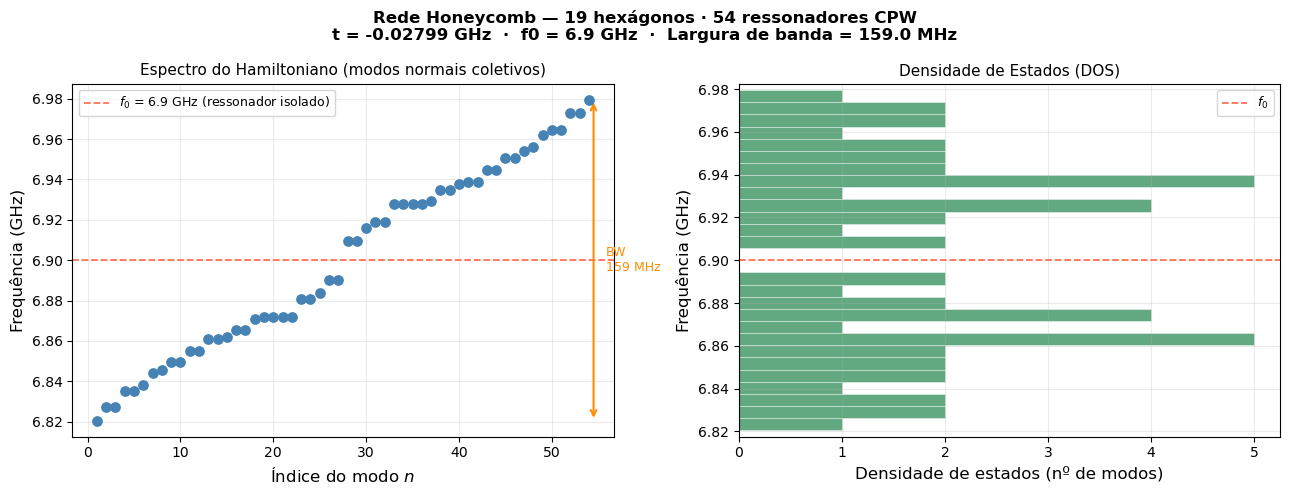

Modos com degenerência (Δf < 0.5 MHz): 22


In [10]:
n_modes   = np.arange(1, N + 1)
bandwidth = eigenvalues.max() - eigenvalues.min()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Painel esquerdo: espectro ω vs n ──────────────────────────────
ax1 = axes[0]
ax1.scatter(n_modes, eigenvalues, color='steelblue', s=45, zorder=5)
ax1.axhline(F_GHZ, color='tomato', linestyle='--', linewidth=1.3,
            label=f'$f_0$ = {F_GHZ} GHz (ressonador isolado)', alpha=0.9)
ax1.set_xlabel('Índice do modo $n$', fontsize=12)
ax1.set_ylabel('Frequência (GHz)', fontsize=12)
ax1.set_title('Espectro do Hamiltoniano (modos normais coletivos)', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.25)

bw_mhz = bandwidth * 1e3
ax1.annotate('', xy=(N + 0.5, eigenvalues.max()),
             xytext=(N + 0.5, eigenvalues.min()),
             arrowprops=dict(arrowstyle='<->', color='darkorange', lw=1.5))
ax1.text(N + 1.8, eigenvalues.mean(),
         f'BW\n{bw_mhz:.0f} MHz',
         color='darkorange', fontsize=9, va='center', ha='left')

# ── Painel direito: densidade de estados ──────────────────────────
ax2 = axes[1]
ax2.hist(eigenvalues, bins=28, orientation='horizontal',
         color='seagreen', alpha=0.75, edgecolor='white', linewidth=0.4)
ax2.axhline(F_GHZ, color='tomato', linestyle='--', linewidth=1.3,
            label='$f_0$', alpha=0.9)
ax2.set_xlabel('Densidade de estados (nº de modos)', fontsize=12)
ax2.set_ylabel('Frequência (GHz)', fontsize=12)
ax2.set_title('Densidade de Estados (DOS)', fontsize=11)
ax2.set_ylim(eigenvalues.min() - 0.003, eigenvalues.max() + 0.003)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.25)

title_line1 = f'Rede Honeycomb — 19 hexágonos · 54 ressonadores CPW'
title_line2 = f't = {t:.5f} GHz  ·  f0 = {F_GHZ} GHz  ·  Largura de banda = {bw_mhz:.1f} MHz'
fig.suptitle(title_line1 + '\n' + title_line2, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('espectro_honeycomb.png', dpi=150, bbox_inches='tight')
plt.show()

n_degen = sum(1 for i in range(len(eigenvalues)-1)
              if abs(eigenvalues[i] - eigenvalues[i+1]) * 1e3 < 0.5)
print(f"Modos com degenerência (Δf < 0.5 MHz): {n_degen}")